# Homework Assignment 3
Return this notebook (filled with your answers) by the deadline via mycourses. Also provide pdf printout of the notebook.

Maximum points from this HW3 is *28P.*

Note that the notebook that you submit needs to work. Reduction of points may be possible if it does not.

Name: **Bui Minh Anh Pham** <br>
Student number: **1024739**

In [39]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import ElasticNet, Lasso, LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

In [40]:
from tqdm import tqdm
import seaborn as sns

In [41]:
# might be useful in some installations)
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

##  Question 1: look at the data (basic operations)  [6P.] 
**Load the data in _prostate.csv_ to your workspace.** The example data originates from a 1989 study by Stamey et al., which explored the correlation between Prostate Specific Antigen (PSA) levels and various clinical measures in 97 men about to receive radical prostatectomy. The objective is to predict the logarithm of PSA (lpsa) using several measurements. These include:
- the logarithm of cancer volume (lcavol),
- logarithm of prostate weight (lweight),
- age,
- logarithm of benign prostatic hyperplasia amount (lbph),
- seminal vesicle invasion (svi),
- logarithm of capsular penetration (lcp),
- Gleason score (gleason),
- the percentage of Gleason scores 4 or 5 (pgg45).

Taking the logarithm of various features is a common feature engineering techique. It often reduces the scale of outliers, and transforms skewed datasets closer to normal distributions.

In [42]:
data_table = pd.read_csv('datasets/prostate.csv', sep='\t')
predictors=list(data_table.columns[:-2])
data_table

,lcavol,lweight,age,lbph,svi,lcp,gleason,pgg45,lpsa,train
0,-0.579818,2.769459,50,-1.386294,0,-1.386294,6,0,-0.430783,T
1,-0.994252,3.319626,58,-1.386294,0,-1.386294,6,0,-0.162519,T
2,-0.510826,2.691243,74,-1.386294,0,-1.386294,7,20,-0.162519,T
3,-1.203973,3.282789,58,-1.386294,0,-1.386294,6,0,-0.162519,T
4,0.751416,3.432373,62,-1.386294,0,-1.386294,6,0,0.371564,T
5,-1.049822,3.228826,50,-1.386294,0,-1.386294,6,0,0.765468,T
6,0.737164,3.473518,64,0.615186,0,-1.386294,6,0,0.765468,F
7,0.693147,3.539509,58,1.536867,0,-1.386294,6,0,0.854415,T
8,-0.776529,3.539509,47,-1.386294,0,-1.386294,6,0,1.047319,F
9,0.223144,3.244544,63,-1.386294,0,-1.386294,6,0,1.047319,F


### 1 a)
Make a  scatterplot matrix of the prostate cancer variables,  where the first row shows the response against each of the predictors in turn.

**Hint:** you should get the same picture that  is displayed in Figure 1.1., page 3,  of  Hastie et al. (2017). 
https://hastie.su.domains/ElemStatLearn/printings/ESLII_print12_toc.pdf.download.html

<div>
<img src="./figures/scatterplot_matrix.png" width="500"/>
</div>


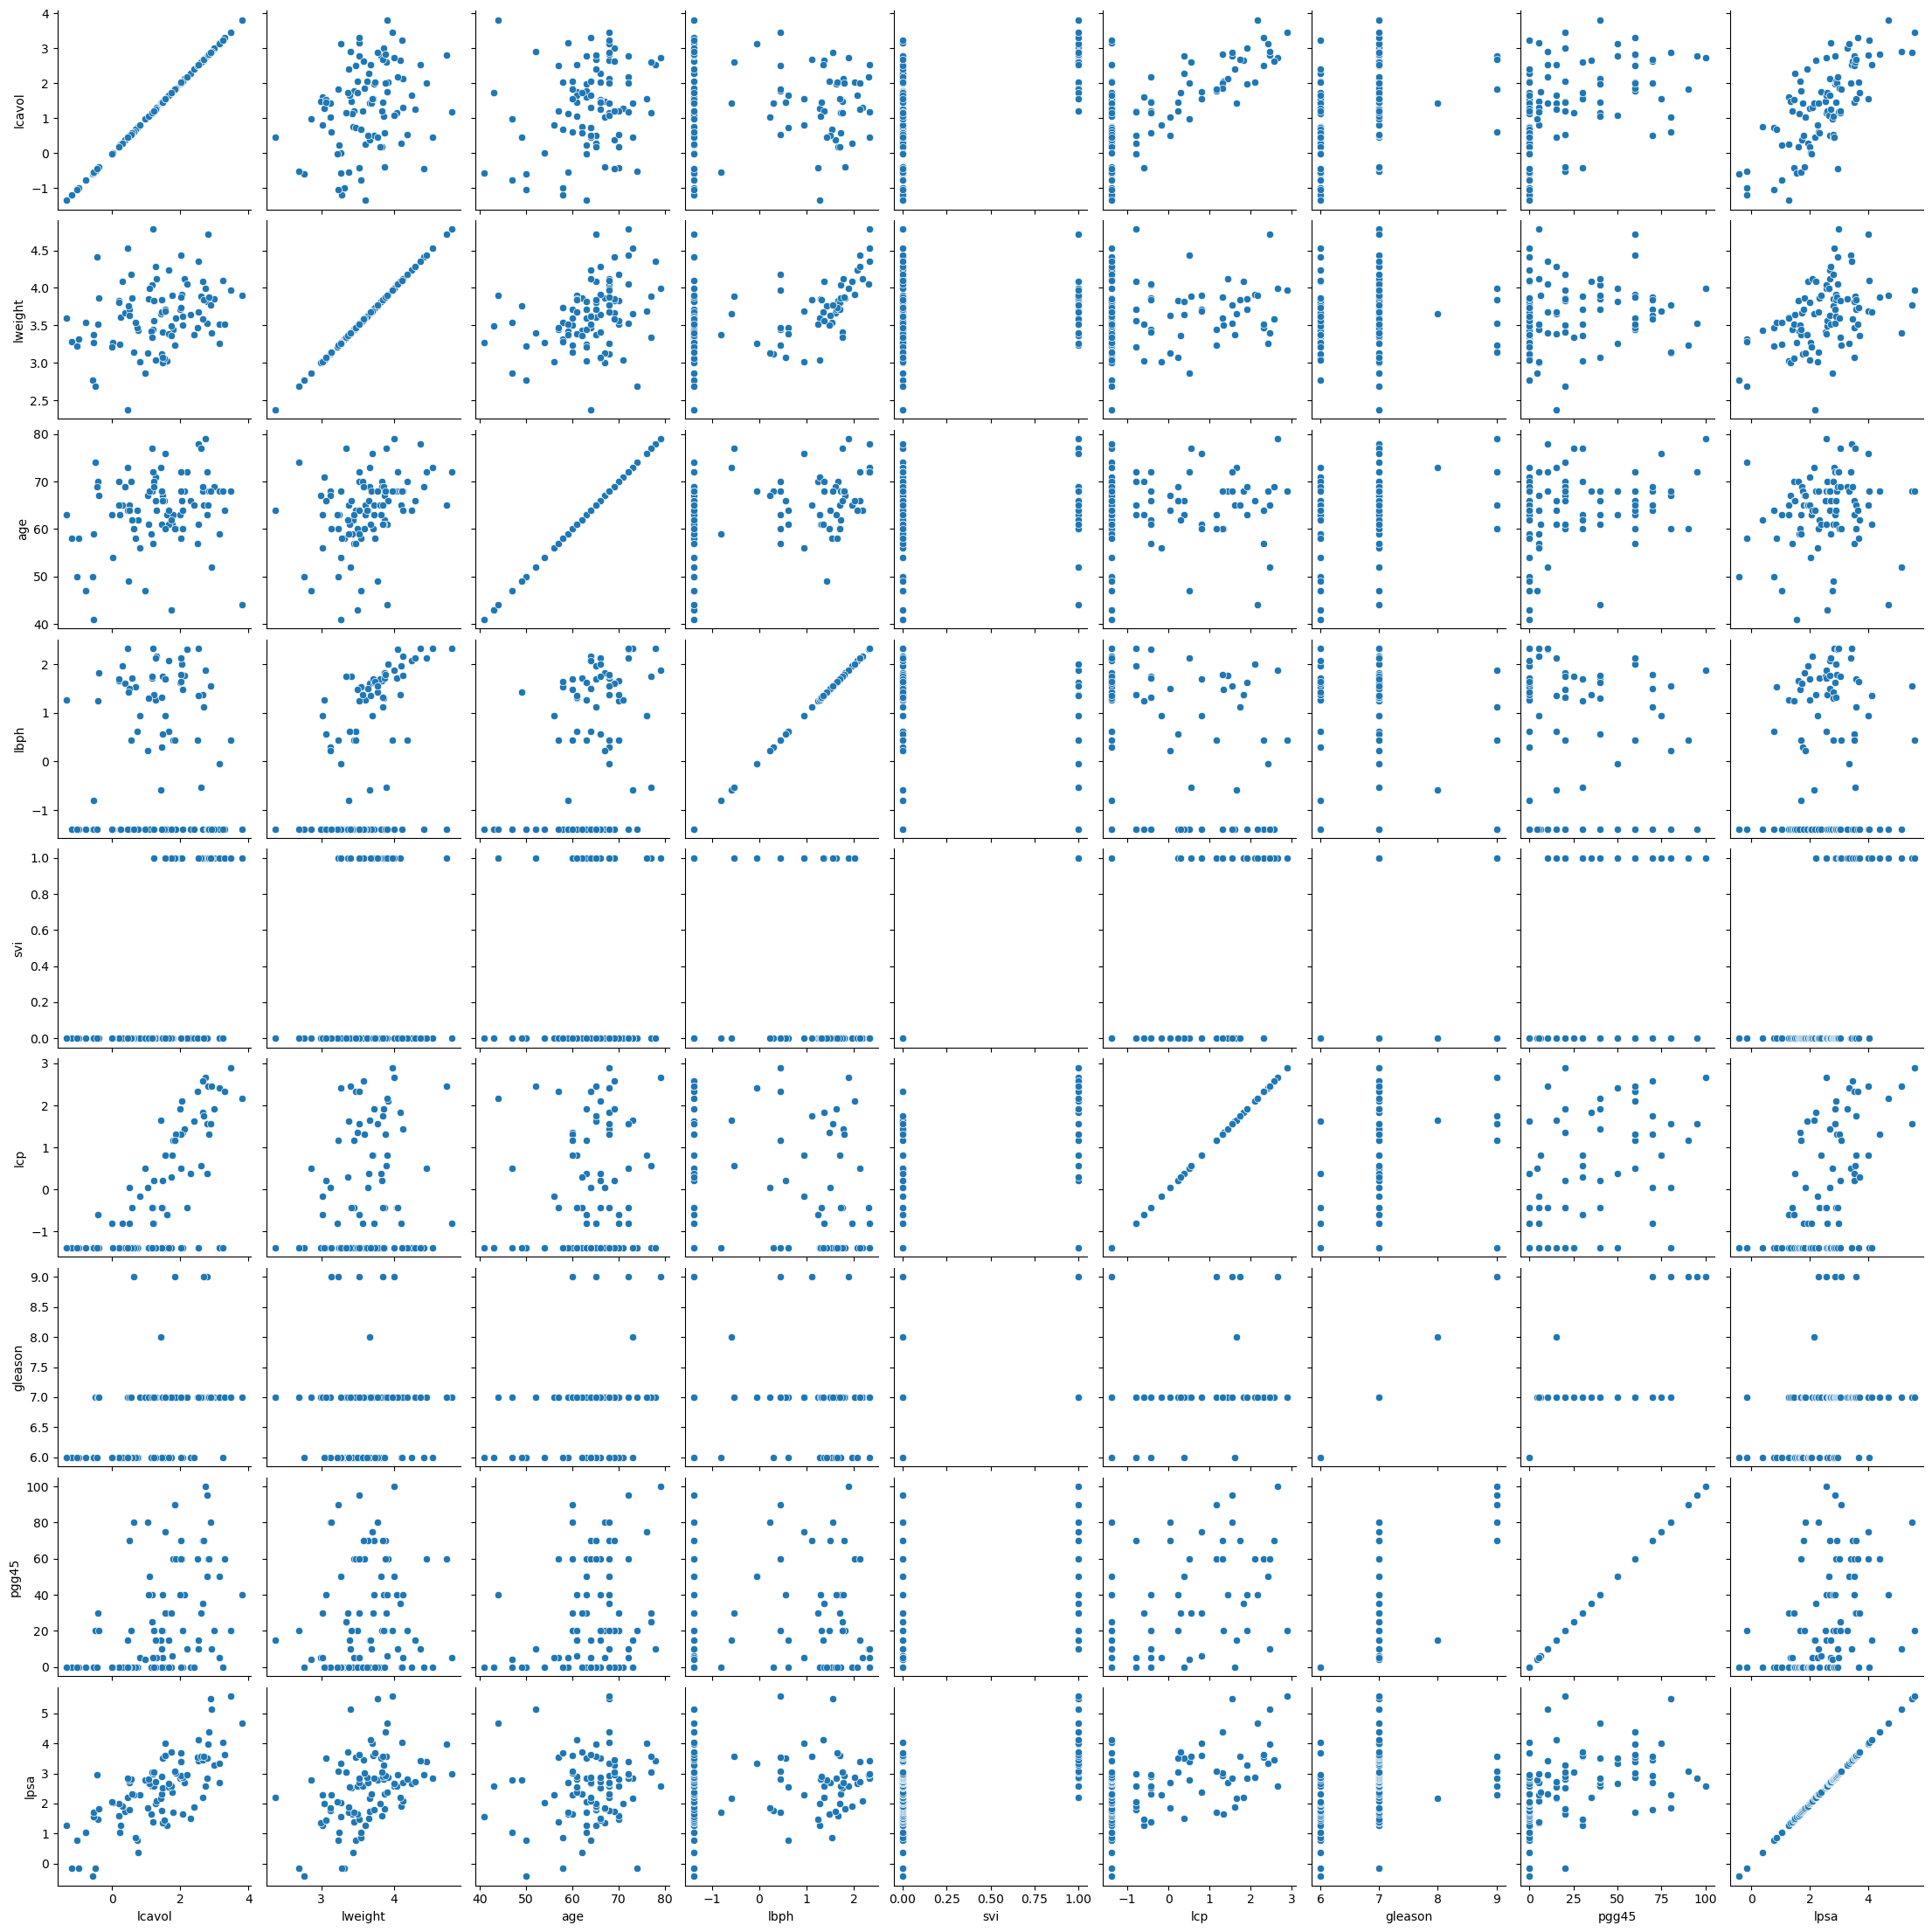

In [43]:
# your solution here
sns.pairplot(data_table, diag_kind=None)

### 1 b)
Center and standardize all predictors to have a mean of zero and unit sample variance. Do this by hand or by using tools from `sklearn`.

In [44]:
# your solution here
scaler = StandardScaler()

data_table[predictors] = scaler.fit_transform(data_table[predictors])
data_table.head()

,lcavol,lweight,age,lbph,svi,lcp,gleason,pgg45,lpsa,train
0,-1.645861,-2.016634,-1.872101,-1.030029,-0.525657,-0.867655,-1.047571,-0.868957,-0.430783,T
1,-1.999313,-0.725759,-0.791989,-1.030029,-0.525657,-0.867655,-1.047571,-0.868957,-0.162519,T
2,-1.587021,-2.200154,1.368234,-1.030029,-0.525657,-0.867655,0.344407,-0.156155,-0.162519,T
3,-2.178174,-0.812191,-0.791989,-1.030029,-0.525657,-0.867655,-1.047571,-0.868957,-0.162519,T
4,-0.510513,-0.461218,-0.251933,-1.030029,-0.525657,-0.867655,-1.047571,-0.868957,0.371564,T


### 1 c) 
Split data into the training and test sets, according to the labels in the `train` column of the `data_table`

In [45]:
# your solution here
train_data = data_table[data_table['train'] == 'T']
test_data = data_table[data_table['train'] == 'F']

train_data.head(), test_data.head()

(     lcavol   lweight       age      lbph       svi       lcp   gleason  \
 0 -1.645861 -2.016634 -1.872101 -1.030029 -0.525657 -0.867655 -1.047571   
 1 -1.999313 -0.725759 -0.791989 -1.030029 -0.525657 -0.867655 -1.047571   
 2 -1.587021 -2.200154  1.368234 -1.030029 -0.525657 -0.867655  0.344407   
 3 -2.178174 -0.812191 -0.791989 -1.030029 -0.525657 -0.867655 -1.047571   
 4 -0.510513 -0.461218 -0.251933 -1.030029 -0.525657 -0.867655 -1.047571   
 
       pgg45      lpsa train  
 0 -0.868957 -0.430783     T  
 1 -0.868957 -0.162519     T  
 2 -0.156155 -0.162519     T  
 3 -0.868957 -0.162519     T  
 4 -0.868957  0.371564     T  ,
       lcavol   lweight       age      lbph       svi       lcp   gleason  \
 6  -0.522668 -0.364678  0.018095  0.356701 -0.525657 -0.867655 -1.047571   
 8  -1.813627 -0.209841 -2.277143 -1.030029 -0.525657 -0.867655 -1.047571   
 9  -0.961052 -0.901927 -0.116919 -1.030029 -0.525657 -0.867655 -1.047571   
 14 -0.122844 -0.438585 -0.927003 -1.030029 -0.

### 1 d)
 Fit a LS linear regression (with intercept) on the training set.  Report the estimated regression coefficients. Also plot the residuals versus observation number.


Hint: you should get exactly the same results as given in Table 3.2, page 50, of Hastie et al. (2017, 12th print) and shown below: 
| Term | Coefficient | Std. Error | Z Score|
| -- | -- | -- | -- |
| Intercept | 2.46 | 0.09 | 27.60 |
lcavol | 0.68 | 0.13 | 5.37 |
lweight | 0.26 | 0.10 | 2.75 |
age | −0.14 | 0.10 | −1.40 |
lbph | 0.21 | 0.10 | 2.06 |
svi | 0.31 | 0.12 | 2.47 |
lcp | −0.29 | 0.15 | −1.87 |
gleason | −0.02 | 0.15 | −0.15 |
pgg45 | 0.27 | 0.15 | 1.74 |

        Term  Coefficient
0  Intercept     2.464933
1     lcavol     0.676016
2    lweight     0.261694
3        age    -0.140734
4       lbph     0.209061
5        svi     0.303623
6        lcp    -0.287002
7    gleason    -0.021195
8      pgg45     0.265576


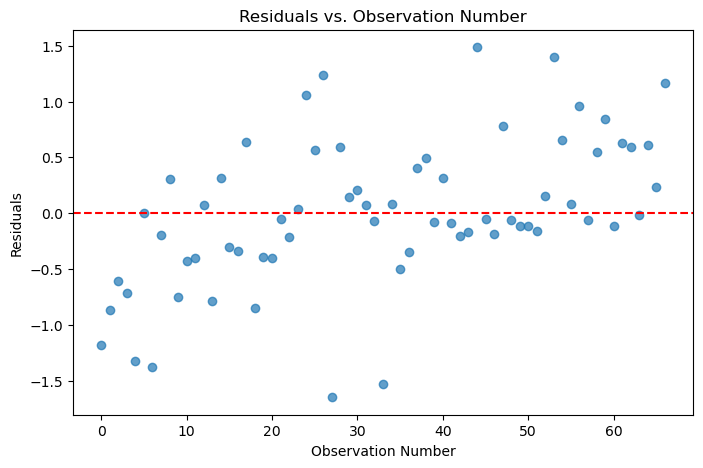

In [46]:
# your solution here
X_train = train_data[predictors]
y_train = train_data["lpsa"]

ls_model = LinearRegression(fit_intercept=True)
ls_model.fit(X_train, y_train)

coefficients = pd.DataFrame({
    "Term": ["Intercept"] + predictors,
    "Coefficient": [ls_model.intercept_] + list(ls_model.coef_)
})
print(coefficients)

y_train_pred = ls_model.predict(X_train)
residuals = y_train - y_train_pred

plt.figure(figsize=(8, 5))
plt.scatter(range(len(residuals)), residuals, alpha=0.7)
plt.axhline(y=0, color="r", linestyle="--")
plt.xlabel("Observation Number")
plt.ylabel("Residuals")
plt.title("Residuals vs. Observation Number")
plt.show()

### 1 e)
Compute the mean squared prediction error (MSPE) on the test set, where MSPE is defined as 
$$ \text{MSPE} = \frac{1}{N_{\text{test}}} \sum_{i \in I_{\text{test}}} (y_i - \hat y_i)^2.$$
where  $ I_{\text{test}}$ denotes the indices in the test set.  

One should obtain $\text{PE} = 0.5213$ or something is computed incorrectly!

In [47]:
# your solution here
X_test = test_data[predictors]
y_test = test_data["lpsa"]

y_test_pred = ls_model.predict(X_test)

mspe = np.mean((y_test - y_test_pred) ** 2)
mspe

0.5212740055076002

### 1 f)
* Compute and report the correlation matrix of predictors variables in the training set.
* Write a function named `maxcor`that identifies the largest correlation between the predictors and reports it in the form: <br>
<code>max correlation (3 decimal accuracy) is  XXX  between predictors  XXX and  XXX.</code>
<br>
The template of the function is given below. 

**Hint:** you should get **exactly the same values** as in Table 3.1 of Hastie et al (2017, 12th printing, p. 50) and shown below:

|    | lweight   | age   | lbph  | svi   | lcp       | gleason | pgg45| 
| --------- | ----- | ----- | ----- | --------- | ----- | ----- | ----- |
| lweight   | 0.300 |       |       |           |       |       |       | 
| age       | 0.286 | 0.317 |       |           |       |       |       | 
| lbph      | 0.063 | 0.437 | 0.287 |           |       |       |       | 
| svi       | 0.593 | 0.181 | 0.129 | −0.139    |       |       |       | 
| lcp       | 0.692 | 0.157 | 0.173 | −0.089    | 0.671 |       |       | 
| gleason   | 0.426 | 0.024 | 0.366 | 0.033     | 0.307 | 0.476 |       | 
| pgg45     | 0.483 | 0.074 | 0.276 | −0.030    | 0.481 | 0.663 | 0.757 | 

In [48]:
corr_matrix = train_data[predictors].corr()
print("Correlation Matrix of Predictors (Training Set):")
print(corr_matrix)


def maxcor(corr,preds):
    """ 
    returns the maximum correlation value and the features which attain the maximum correlation 
    """
    # code 
    corr_abs = corr.abs()
    np.fill_diagonal(corr_abs.values, 0)
    
    mxcor = corr_abs.max().max()
    ix, iy = np.where(corr_abs == mxcor)
    ix, iy = ix[0], iy[0]  # Extract first occurrence

    print('max correlation is {0:.3f} between predictors {1} and {2}'.format(mxcor,preds[ix],preds[iy]))
    return mxcor,preds[ix],preds[iy]      
max_correlation, pred1, pred2 = maxcor(corr_matrix, predictors)

Correlation Matrix of Predictors (Training Set):
           lcavol   lweight       age      lbph       svi       lcp   gleason  \
lcavol   1.000000  0.300232  0.286324  0.063168  0.592949  0.692043  0.426414   
lweight  0.300232  1.000000  0.316723  0.437042  0.181054  0.156829  0.023558   
age      0.286324  0.316723  1.000000  0.287346  0.128902  0.172951  0.365915   
lbph     0.063168  0.437042  0.287346  1.000000 -0.139147 -0.088535  0.032992   
svi      0.592949  0.181054  0.128902 -0.139147  1.000000  0.671240  0.306875   
lcp      0.692043  0.156829  0.172951 -0.088535  0.671240  1.000000  0.476437   
gleason  0.426414  0.023558  0.365915  0.032992  0.306875  0.476437  1.000000   
pgg45    0.483161  0.074166  0.275806 -0.030404  0.481358  0.662533  0.757056   

            pgg45  
lcavol   0.483161  
lweight  0.074166  
age      0.275806  
lbph    -0.030404  
svi      0.481358  
lcp      0.662533  
gleason  0.757056  
pgg45    1.000000  
max correlation is 0.757 between predicto

## Question 2: Cyclic Coordinate Descent (CCD) for lasso and ElasticNet [6P.]
Read lecture notes discussing the cyclic coordinate descent algorithm for lasso and elastic net. <br>


### Question 2a [3P.] 
Implement the basic CCD Elastic Net (EN) algorithm (<code>ccden</code>) (see *Algorithm 1.3*) by yourself by writing a function named <code>ccden</code> below.  Recall that this algorithm assumes that the predictors are standardized. 

In [49]:
def soft_threshold(x, lam):
    return np.sign(x)*np.maximum(np.abs(x) - lam, 0)

In [50]:
def ccden(y, X, b_init, lam, alpha=1.0, delta=1e-4, max_iter=10000):
    """
    my implementation of the ccden algorithm
    Parameters:
    - y: Response variable (vector)
    - X: Predictor variables (matrix) (assumed to be standardized)
    - b_init: Initial coefficients (vector)
    - lam: Regularization parameter (lambda)
    - alpha: Elastic Net mixing parameter (1 = Lasso, 0 = Ridge)
    - delta: Convergence threshold
    - max_iter: Maximum number of iterations

    Returns:
    - b: Estimated coefficients (vector)
    - beta_history: Array tracking coefficient updates over iterations
    """
    n, p = X.shape

    b = b_init.copy()
    beta_history = [b.copy()]

    for iteration in range(max_iter):
        b_old = b.copy()

        for j in range(p):
            r_j = y - (X @ b) + X[:, j] * b[j]
            rho_j = X[:, j].T @ r_j / n  

            b[j] = soft_threshold(rho_j, lam * alpha) / (1 + lam * (1 - alpha))

        beta_history.append(b.copy())

        if np.linalg.norm(b - b_old, ord=2) < delta:
            break

    return b, np.array(beta_history)

### Question 2b [2P.] 
But did my code work? Let's check this out.  So your <code>ccden</code> function has produced you an estimate  that minimizes $\frac{1}{2N} \| \mathbf{y} - \mathbf{X} \boldsymbol{\beta} \|_2^2 + \lambda \alpha \| \boldsymbol{\beta}\|_1 + \frac 1 2 \lambda (1- \alpha)\|\boldsymbol{\beta} \|_2^2 $.  

Recall the subgradient optimality conditions: 
 $\hat{\boldsymbol{\beta}}$ is the solution for EN optimization problem with given penalty parameters if and only if equation (1.27) in Lecture notes holds.

1. First center both the response and predictor variables of the prostate cancer training data set you created in 1(c). 
2. Then standardize the predictors. 
3. Give this training data as inputs to <code>ccden</code> function to find the solution $\hat{\boldsymbol{\beta}}(\lambda,\alpha)$  with a penalty parameter value $\lambda=0.3$ and $\alpha=1$ (lasso) and $\alpha=0.9$. The initial value of iteration <code>beta_init</code> should be a vector of zeros.
4. Report the solutions 
5. Verify that  the subgradient optimality condition holds for your solutions.   <br>

**Note**: Essentially, items 1 and 2 perform Steps 1 and 2 of Algorithm 1.1 (Lasso).  

In [51]:
lam = 0.3 # This is the penalty for lasso
al = 0.9 # This is the EN penalty parameter
alpha_lasso = 1.0 

In [52]:
# 1. Center
y_train_centered = y_train - np.mean(y_train)
X_train_centered = X_train - np.mean(X_train, axis=0)

In [53]:
# 2. Standardize predictors
X_train_standardized = X_train_centered / X_train_centered.std(axis=0, ddof=0)
X0 = X_train_standardized
y0 = y_train_centered

In [54]:
# 3. compute solution for the training data
beta_init = np.zeros(X_train_standardized.shape[1]) 
beta_lasso_ccd, beta_history_lasso = ccden(y_train_centered.values, X_train_standardized.values, beta_init, lam, alpha=alpha_lasso)
beta_en_ccd, beta_history_en = ccden(y_train_centered.values, X_train_standardized.values, beta_init, lam, alpha=al)

In [55]:
# 4. report the solutions
beta_comparison = pd.DataFrame(
    data=[beta_lasso_ccd, beta_en_ccd],
    index=['Lasso (CCD)', 'EN (CCD)'],
    columns=predictors
)
beta_comparison

,lcavol,lweight,age,lbph,svi,lcp,gleason,pgg45
Lasso (CCD),0.521449,0.118423,0.0,0.0,0.036942,0.0,0.0,0.0
EN (CCD),0.511491,0.141786,0.0,0.0,0.066618,0.0,0.0,0.0


In [56]:
# 5. Verify that subgradient equations hold:

**Note**: You can verify that your code works by checking that  it returns the same value as the following code: 

In [57]:
# y0 and X0 are here the centered / standardized data
regLasso0 = Lasso(fit_intercept=False,alpha=lam).fit(X0, y0)
regEN0 = ElasticNet(fit_intercept=False,alpha=lam,l1_ratio=al).fit(X0, y0)
beta_las_star = regLasso0.coef_
beta_en_star = regEN0.coef_
pd.DataFrame(data=(beta_las_star, beta_en_star),index = ['Lasso', 'EN'],columns=predictors)

,lcavol,lweight,age,lbph,svi,lcp,gleason,pgg45
Lasso,0.521421,0.118423,0.0,0.0,0.036958,0.0,0.0,0.0
EN,0.511467,0.141785,0.0,0.0,0.066632,0.0,0.0,0.0


### Qustion 2c [1P.] 
Use the same data set as in question 2b). Show the convergence graphs for CCD.
Use the value <code>beta_las_star</code> (obtained in Note of question 2b)  as the true optimum $\boldsymbol{\beta}^*$ of the lasso objective function.   

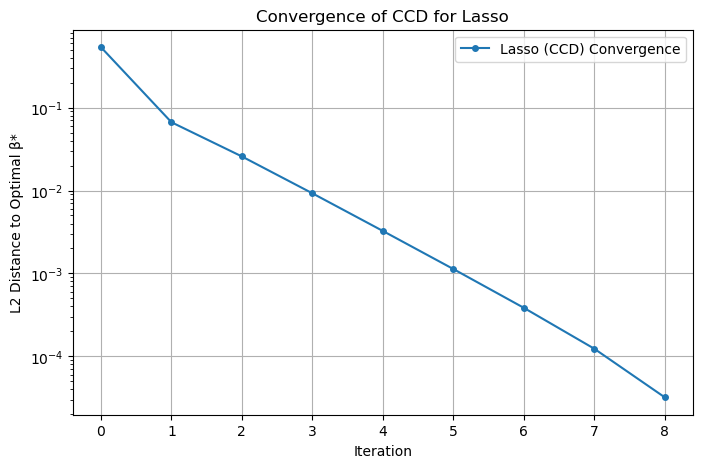

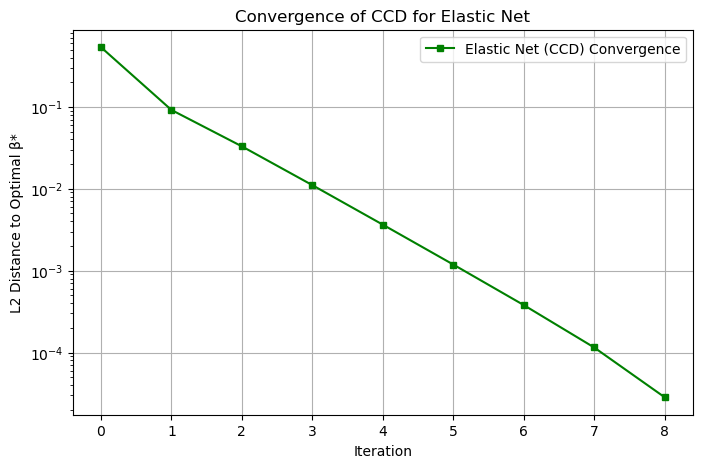

In [58]:
# your code here
convergence_lasso = np.linalg.norm(beta_history_lasso - beta_las_star, axis=1)
convergence_en = np.linalg.norm(beta_history_en - beta_en_star, axis=1)

plt.figure(figsize=(8, 5))
plt.plot(convergence_lasso, marker='o', linestyle='-', markersize=4, label='Lasso (CCD) Convergence')
plt.xlabel("Iteration")
plt.ylabel("L2 Distance to Optimal β*")
plt.title("Convergence of CCD for Lasso")
plt.legend()
plt.yscale('log')  
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(convergence_en, marker='s', linestyle='-', markersize=4, color='green', label='Elastic Net (CCD) Convergence')
plt.xlabel("Iteration")
plt.ylabel("L2 Distance to Optimal β*")
plt.title("Convergence of CCD for Elastic Net")
plt.legend()
plt.yscale('log')  
plt.grid(True)
plt.show()

***
## Question 3: Lasso/EN solution path [6P.]

### Question 3a [1P.]
Then transform the obtained estimates to original scale and compute the intercept, i.e., apply steps 4 and 5 of *Algorithm 1.1*. Report the obtained values of regression coefficents  $\hat{\boldsymbol{\beta}}(\lambda,\alpha)$ and intercept $\hat{\beta}_0(\lambda,\alpha)$ when $(\lambda,\alpha) =(0.3,1)$  and $(\lambda,\alpha)= (0,3,0.9)$. Note that former ($\alpha=1$) yields the lasso solution for the original training data $\mathbf{y}$ and $\mathbf{X}$. Compare the found lasso and EN solution with the LSE solution you computed in question 1d). 

In [59]:
# Your solution here
intercept_lasso = np.mean(y_train) - np.dot(np.mean(X_train, axis=0), beta_lasso_ccd)
intercept_en = np.mean(y_train) - np.dot(np.mean(X_train, axis=0), beta_en_ccd)

beta_lasso_original = beta_lasso_ccd / X_train.std(axis=0, ddof=0)
beta_en_original = beta_en_ccd / X_train.std(axis=0, ddof=0)

intercept_lse = ls_model.intercept_
beta_lse = ls_model.coef_

beta_comparison_original = pd.DataFrame(
    data=[np.append(intercept_lasso, beta_lasso_original), 
          np.append(intercept_en, beta_en_original),
          np.append(intercept_lse, beta_lse)],
    index=['Lasso (λ=0.3, α=1)', 'Elastic Net (λ=0.3, α=0.9)', 'LSE (Least Squares)'],
    columns=['Intercept'] + predictors
)
beta_comparison_original

,Intercept,lcavol,lweight,age,lbph,svi,lcp,gleason,pgg45
"Lasso (λ=0.3, α=1)",2.468711,0.495763,0.106698,0.000000,0.000000,0.036500,0.000000,0.000000,0.000000
"Elastic Net (λ=0.3, α=0.9)",2.468024,0.486297,0.127748,0.000000,0.000000,0.065821,0.000000,0.000000,0.000000
LSE (Least Squares),2.464933,0.676016,0.261694,-0.140734,0.209061,0.303623,-0.287002,-0.021195,0.265576


### Question 3b [3P.] 
Now you have all codes necessary to implement the EN path algorithm (i.e., Algorithm 1.4 (enpath)) that computes the EN/Lasso solution path over a grid $\lambda_0 > \lambda_1 > \cdots > \lambda_L$  values. Note that you should utilize your `ccden`  function you wrote in Problem 2a in your function. The function `generate_lambdas` that  computes the  grid of penalty parameters is provided below as well as the template for enpath function.  

In [60]:
def generate_lambdas(X,y,alpha=1,L=100,eps=10**-4):
    """ 
    function to generate a grid of penalty parameter values lambda_0 > lambda_1  > ... > lambda_L
    on log-scale, where lambda_0 is the smallest penalty parameter value 
    yielding an all zero solution, and lambda_j = eps^(1/L) * lambda_(j-1)

        X: the training data of predictors shape (N,p), where norm(X[:,j])**2=N
        y: the training data of responses of 
    alpha: the elastic net penalty parameter (real between [0,1])
       L : Positive integer, the number of lambda values EN/Lasso uses.  
           Default is L=100. 
      eps: Positive scalar, the ratio of the smallest to the 
           largest Lambda value in the grid. Default is eps = 10^-4. 
    output:
      lamgrid: grid of penalty parameters
    """
    assert((np.linalg.norm(X,axis=0)**2-X.shape[0]).all() ==0)
    assert(alpha>0 and alpha <= 1)
    N = X.shape[0]
    lam0 = np.linalg.norm(X.T @ y,np.inf)/(N*alpha) # smallest penalty value giving zero solution
    lamgrid = np.power(eps,np.arange(0,L+1)/L)*lam0 # grid of penalty values
    return lamgrid

In [61]:
def enpath(X, y,Xt=[],yt=[],alpha=1.0,L=100,eps=10**-4,max_iter=1000):
    """
    function to compute the solution of elastic net over a grid of l_1-penalty lambda values 

        X: the training data of predictors shape (N,p)
        y: the training data of responses of shape (N,) 
       L : Positive integer, the number of lambda values EN/Lasso uses.  
           Default is L=100. 
      eps: Positive scalar, the ratio of the smallest to the 
           largest Lambda value in the grid. Default is eps = 10^-4=lambda_min/lambda_max
      iter: maximum number of iterations of cyclic coordinate descent algorithm
      
    OUTPUT:
      betas: matrix of size (L+1,p) of regression coefficients in the path
      beta0: matrix of size (L+1,) of intercepts

    Note:  generate lambda values using  generate_lambdas and use your previous ccden funcion 
    to compute the regression estimators  
    """
  
    # 1. Center
    y_mean, X_mean = np.mean(y), np.mean(X, axis=0)
    y_centered, X_centered = y - y_mean, X - X_mean

    yt_centered, Xt_centered = yt - y_mean, Xt - X_mean

    # 2. Standardize predictors
    scaler = StandardScaler()
    X_standardized = scaler.fit_transform(X_centered)
    Xt_standardized = scaler.transform(Xt_centered)

    
    # 3. generate the grid 
    lamgrid = generate_lambdas(X_standardized, y_centered, alpha, L, eps)

    # 4. compute estimators for penalty parameters on the grid
    betas, beta0s, mspe_values = [], [], []
    beta_init = np.zeros(X_standardized.shape[1])

    for lam in lamgrid:
        beta, _ = ccden(y_centered, X_standardized, beta_init, lam, alpha, max_iter=max_iter)
        
        # Convert beta coefficients back to original scale
        beta_original = beta / scaler.scale_
        beta0 = y_mean - np.dot(X_mean, beta_original)

        betas.append(beta_original)
        beta0s.append(beta0)

        # Compute mean squared prediction error
        y_pred = Xt_standardized @ beta + beta0
        mspe_values.append(mean_squared_error(yt, y_pred))
    
    # 5. Transform to orginal scale 
        
    # return my estimates
    return np.array(betas), np.array(beta0s), lamgrid, np.array(mspe_values) if mspe_values else None

## Question 3c [1P.]
* Then compute the Lasso path (i.e., use $\alpha=1$) and Elastic Net path for $\alpha=0.5$ for the **training data**. 
* Plot the Lasso paths as in the lecturenotes, so using $\sum_{j} | \hat \beta_j(\lambda) | / \sum_{j} |\hat \beta_{LS,j}| $  for values in x-axis for Lasso and $P_{EN}(\hat \beta)/P_{EN}(\hat \beta_{LS})$ for the elastic net. You should obtain the plot that is shown in Figure 3.10, p. 70, of the ESL book (Hastie et al. 2017) for the Lasso.  

<div>
<img src="./figures/figure3dot10.png" width="500"/>
</div>

Your plot should look like the one that is shown above!


In [62]:
alpha = 0.5

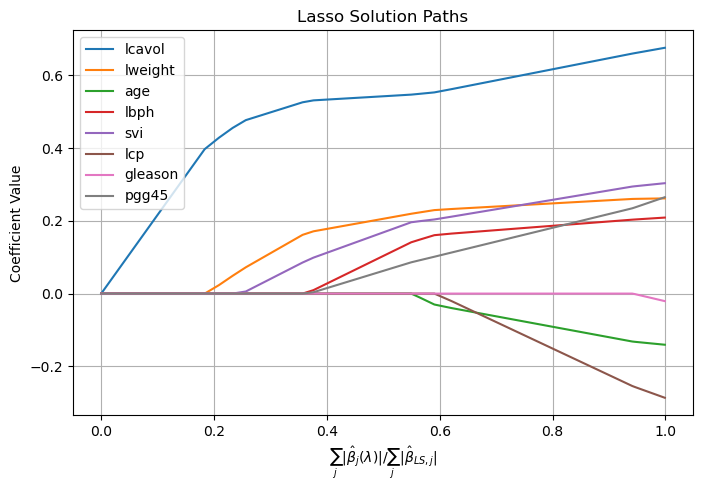

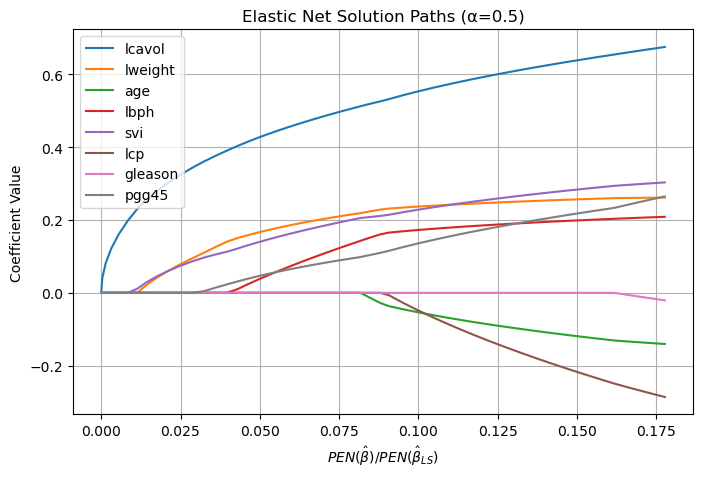

In [63]:
# compute the solutions and plot them 
betas_lasso, beta0s_lasso, lamgrid_lasso, mspe_lasso = enpath(X_train, y_train, X_test, y_test, alpha=1.0)
betas_en, beta0s_en, lamgrid_en, mspe_en = enpath(X_train, y_train, X_test, y_test, alpha=0.5)

lse_model = LinearRegression(fit_intercept=True)
lse_model.fit(X_train, y_train)
beta_lse = np.abs(lse_model.coef_).sum()

lasso_path_x = np.sum(np.abs(betas_lasso), axis=1) / beta_lse

pen_lse = np.sum(beta_lse**2) 
pen_en = np.sum(betas_en**2, axis=1) / pen_lse

plt.figure(figsize=(8, 5))
for i, predictor in enumerate(predictors):
    plt.plot(lasso_path_x, betas_lasso[:, i], label=predictor)

plt.xlabel(r"$\sum_j |\hat{\beta}_j(\lambda)| / \sum_j |\hat{\beta}_{LS,j}|$")
plt.ylabel("Coefficient Value")
plt.title("Lasso Solution Paths")
plt.grid()
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
for i, predictor in enumerate(predictors):
    plt.plot(pen_en, betas_en[:, i], label=predictor)

plt.xlabel(r"$PEN(\hat{\beta}) / PEN(\hat{\beta}_{LS})$")
plt.ylabel("Coefficient Value")
plt.title("Elastic Net Solution Paths (α=0.5)")
plt.grid()
plt.legend()
plt.show()

### Question 3d [1P.] 
​
Find optimal values of $\lambda$. 
* Extend your previous function <code>enpath</code> so that it takes also the test data set as inputs and returns also the Mean Squared Error Prediction (MSPE) on the **test set** for each value of $\lambda$. 
* Plot MSPE versus lambda for both Lasso and EN and find the optimal (lowest) MSE and corresponding value of lambda. You should get the following figure:
<div>
<img src="figures/mse_vs_log_lambda.png" width="500"/>
</div>

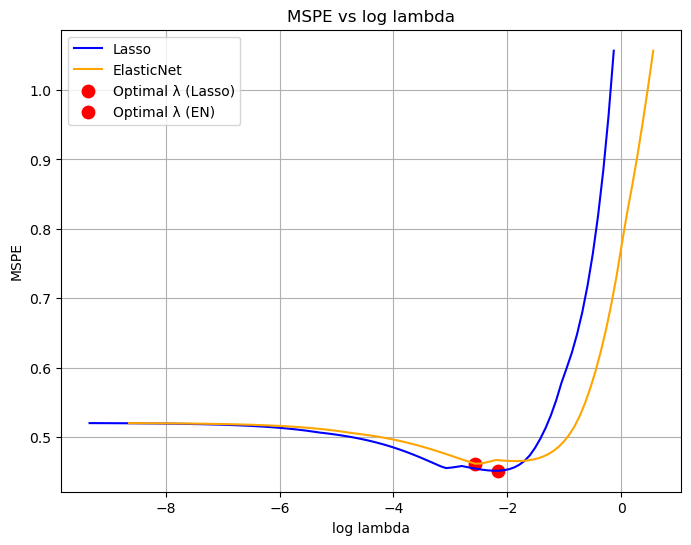

(0.11585900276945647, 0.07672904304180948)

In [64]:
# your code here 
optimal_lam_lasso = lamgrid_lasso[np.argmin(mspe_lasso)]
optimal_lam_en = lamgrid_en[np.argmin(mspe_en)]

plt.figure(figsize=(8, 6))
plt.plot(np.log(lamgrid_lasso), mspe_lasso, label="Lasso", color="blue")
plt.plot(np.log(lamgrid_en), mspe_en, label="ElasticNet", color="orange")
plt.scatter(np.log(optimal_lam_lasso), min(mspe_lasso), color="red", s=80, label="Optimal λ (Lasso)")
plt.scatter(np.log(optimal_lam_en), min(mspe_en), color="red", s=80, label="Optimal λ (EN)")
plt.xlabel("log lambda")
plt.ylabel("MSPE")
plt.title("MSPE vs log lambda")
plt.legend()
plt.grid(True)
plt.show()

optimal_lam_lasso, optimal_lam_en

## Question 4: feature selection using Lasso [4P.]

In [65]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler



In the first part of this exercise we analyzed prostate cancer data set which is a small data set consisting of $8$ hand-crafted features. While Lasso worked well for the task, its main advantage of exploiting sparsity was not so apparent. Not only is sparsity beneficial from a robustness point-of-view by ignoring "meaningless" features, it also works as a powerful **feature selection** technique. 

We will now look at a different prostate cancer dataset (Singh et al., 2002). In this case we have **12,533** genes which we classify into either `normal` or `tumor` categories. The dataset contains only 102 patients, so the problem is $p \gg n$.

Since this is a classification task, we will use **Logistic Regression** to map predictions into binary categories. Let's first load the dataset:

In [66]:
# Read the data from the CSV file
data = pd.read_csv("./datasets/prostate_genes.csv", sep="\t")

feature_matrix = data.drop("Sample",axis=1)
target_vector = data["Sample"]

data.head(3)

,Sample,31307_at,31308_at,31309_r_at,31310_at,31311_at,31312_at,31313_at,31314_at,31315_at,...,100_g_at,101_at,102_at,103_at,104_at,105_at,106_at,107_at,108_g_at,109_at
0,normal,-11.4,2.7,0.6,4.3,28.0,0.3,-17.5,-5.4,7.5,...,72.8,4.1,2.5,5.0,22.5,7.3,14.0,19.3,-39.5,37.3
1,normal,-1.0,-1.0,0.0,-1.0,3.0,0.0,-3.0,1.0,-2.0,...,25.0,10.0,2.0,4.0,5.0,1.0,6.0,6.0,0.0,26.0
2,normal,-9.0,-19.0,0.0,0.0,76.0,9.0,-57.0,35.0,23.0,...,111.0,-66.0,12.0,14.0,59.0,16.0,-13.0,-10.0,-156.0,-21.0


### Question 4a [1P.]
* Center and standardize all predictors to have a mean of zero and unit sample variance. Do this by hand or by using tools from `sklearn`. 
* Encode the labels `normal` and `tumor` to categories expected by sklearns classifiers. Use e.g., the `LabelEncoder`.

In [67]:
# your solution
scaler = StandardScaler()
feature_matrix_standardized = pd.DataFrame(
    scaler.fit_transform(feature_matrix),
    columns=feature_matrix.columns
)

label_encoder = LabelEncoder()
target_vector_encoded = label_encoder.fit_transform(target_vector)

### Split the data to a train and test set

In [68]:
# split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(feature_matrix, target_vector, test_size=0.15, random_state=0)

### Question 4b [2P.]
Train sklearns `LogisticRegression` classifier **without penalty term**. i.e., set `penalty=None`.

- Evaluate the models accuracy score on the test set
- Count and print the number of coefficients that are non-zero

In [69]:
# train unpenalized logistic regression model
log_reg = LogisticRegression(penalty="none", max_iter=1000, solver='lbfgs')
log_reg.fit(X_train, y_train)
# evaluate the model
accuracy_unpenalized = log_reg.score(X_test, y_test)
# count and print number of non-zero
num_nonzero_unpenalized = np.count_nonzero(log_reg.coef_)

Next compare results to `LogisticRegression` classifier with $\ell1$ penalty, corresponding to Lasso,  with a regularization strength ($\lambda$) of 5. 
- Evaluate the models accuracy score on the test set
- Count and print the number of coefficients that are non-zero

**Note:** the `LogisticRegression` uses  **inverse** regularization strength for the argument `C` (i.e., $C = 1/\lambda$)

In [70]:
# train logistic regression model with L1 regularization
lasso_lambda = 5
log_reg_l1 = LogisticRegression(penalty="l1", C=1/lasso_lambda, solver='liblinear', max_iter=1000, random_state=0)
log_reg_l1.fit(X_train, y_train)

LogisticRegression(C=0.2, max_iter=1000, penalty='l1', random_state=0,
                   solver='liblinear')

In [71]:
# your code
accuracy_l1 = log_reg_l1.score(X_test, y_test)

num_nonzero_l1 = np.count_nonzero(log_reg_l1.coef_)

results_comparison = pd.DataFrame({
    "Model": ["Unpenalized Logistic Regression", "Lasso Logistic Regression (λ=5)"],
    "Test Accuracy": [accuracy_unpenalized, accuracy_l1],
    "Non-zero Coefficients": [num_nonzero_unpenalized, num_nonzero_l1]
})
results_comparison

,Model,Test Accuracy,Non-zero Coefficients
0,Unpenalized Logistic Regression,0.8125,12533
1,Lasso Logistic Regression (λ=5),0.7500,86


### Question 4c [1P.]
Which genes did Lasso select? Print the names (accession IDs) and coefficient values of selected genes.

Notice that Lasso retained the same accuracy while using only a tiny percentage of the original genes! Lasso is often used as a **feature selection** algorithm for more advanced classification/regression algorithms. For example, we could feed the selected features to a deep learning classifier for potentially even better accuracy.

In [72]:
# your code
selected_genes_mask = log_reg_l1.coef_.flatten() != 0  
selected_genes = np.array(X_train.columns)[selected_genes_mask]  
selected_coefficients = log_reg_l1.coef_.flatten()[selected_genes_mask]  

selected_genes_df = pd.DataFrame({
    "Gene (Accession ID)": selected_genes,
    "Coefficient Value": selected_coefficients
}).sort_values(by="Coefficient Value", ascending=False)  
pd.set_option("display.max_rows", None) 
selected_genes_df

   Gene (Accession ID)  Coefficient Value
44            32786_at           0.006976
33            37639_at           0.005952
29            41468_at           0.005920
27            38604_at           0.004097
36            40448_at           0.003997
76            875_g_at           0.003425
49            36587_at           0.002556
2             31509_at           0.001799
59            38126_at           0.001797
1             31505_at           0.001771
72           1612_s_at           0.001646
38          41152_f_at           0.001391
52            36666_at           0.001359
67          41483_s_at           0.001255
51            36638_at           0.001160
4             31527_at           0.001035
65            40886_at           0.001024
35            40435_at           0.001010
28          39645_r_at           0.000908
61            38429_at           0.000629
8             31584_at           0.000583
57          37407_s_at           0.000568
78              767_at           0

# Question 5: Fused Lasso [6P.]

In this part you will repeat the study of Example 2.1. Code below generates the data ($\mathbf{y}$, $\mathbf{X}$, and true regression vector $\boldsymbol{\beta}$)

In [73]:
# Generate the data of Example 2.1 
np.random.seed(0)  #  set random seed for reproducibility 
N = 1000  # sample length 
p = 200  # dimension
rng = np.random.default_rng(42)

# 1. compute covariance matrix for predictors 
rho = 0.7
CScov  = lambda r,p : r*(np.ones((p,p))-np.eye(p)) + np.eye(p) # CS covariance matrix 
M = CScov(rho,p)
X = rng.standard_normal((N,p))
from scipy.linalg import cholesky
X = X @ cholesky(M).T # Let's introduce some correlations among predictors

# Creat the true beta vector
be = np.vstack((np.zeros((int(p/4),1)),-0.5*np.ones((int(p/4),1))))
be = np.vstack((be,0.3*np.ones((int(p/4),1)))) 
be = np.vstack((be,np.zeros((int(p/4),1)))) 

# Createt the response vector
err = rng.standard_normal((N,1)) # noise vector with components from  N(0,1)
y = X @ be + err

## Question 5a [4P.] 
Implement the Fused Lasso algorithm using ADMM. The algorithm uses the iterations in (2.9) - (2.11). Recall that the matrix $\mathbf{D}$ you need to use is the 1st order difference matrix. Use $\rho=100$ for the ADMM parameter.  As termination condition use: 
$$
\| \mathbf{D} \boldsymbol{\beta}^{(k)} - \mathbf{z}^{(k)}  \| < \epsilon
$$
with $\epsilon = 1e^{-5}$. 

In [74]:
MAX_ITER = 30000 # This is the MAX iterations
rho = 100 # Use this as your rho for ADMM 

In [75]:
def ADMM_FL(feature_matrix, target_vector, lam, rho=rho, max_iter=MAX_ITER, eps_tol=1e-5):
    """Linear regression with ADMM and Fused Lasso regularization

    Args:
        feature_matrix (np.array): the feature matrix
        target_vector (np.array): the target vector
        lam (float): the regularization strength
        rho (float): ADMM parameter
        max_iter (int, optional): iteration count. Defaults to MAX_ITER.
        eps_tol (float, optional): tolerance. Defaults to 1e-5.
    Output:
        coef (np.array): the Fused Lasso estimate of regression coefficient vector beta
    """
    # your code here 
    y_vec = np.ravel(target_vector)
    n, p = feature_matrix.shape
    D = np.diff(np.eye(p), axis=0)  
    A = feature_matrix.T.dot(feature_matrix) + rho * (D.T.dot(D))
    L_factor = np.linalg.cholesky(A)
    
    beta = np.zeros(p)
    z = np.zeros(p - 1)
    u = np.zeros(p - 1)
    
    for i in range(max_iter):
        rhs = feature_matrix.T.dot(y_vec) + rho * D.T.dot(z - u)
        temp = np.linalg.solve(L_factor, rhs)
        beta_new = np.linalg.solve(L_factor.T, temp)
        
        v = D.dot(beta_new) + u
        z_new = np.sign(v) * np.maximum(np.abs(v) - lam / rho, 0)
        

        u += D.dot(beta_new) - z_new
        
        if np.linalg.norm(D.dot(beta_new) - z_new) < eps_tol:
            beta = beta_new
            break
        
        beta = beta_new
        z = z_new
    
    return beta

## Question 5 b [2P.]
* Compute the Fused-Lasso solutions when the penalty parameter is $\lambda = 30$ and $\lambda =120$. 
* Plot the obtained regression coefficient values as in Figure 2.2 along with true coefficients and LS-regression coefficient values (use model withour intercept). 

<div>
<img src="./figures/flreg.png" width="900"/>
</div>

Your plot should look like the one that is shown above!


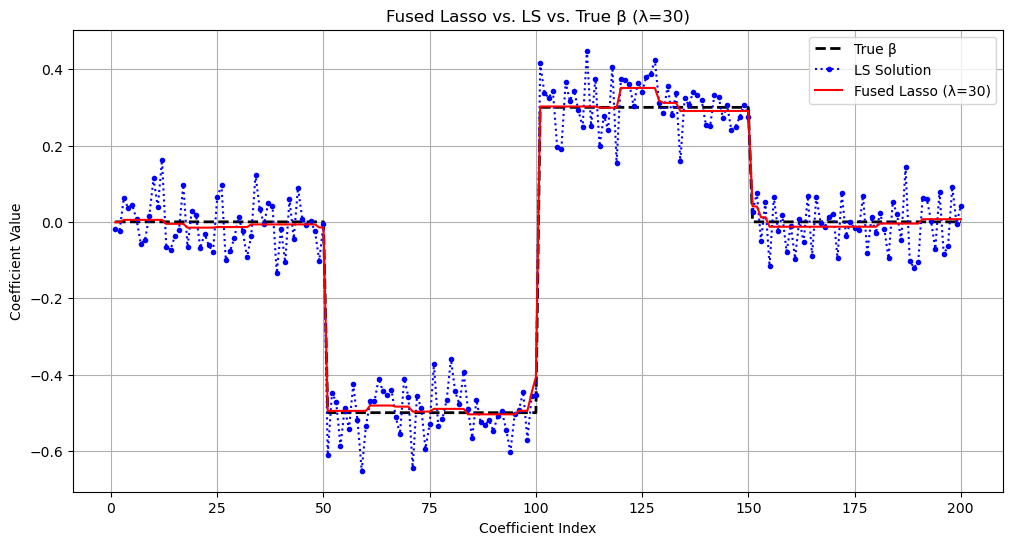

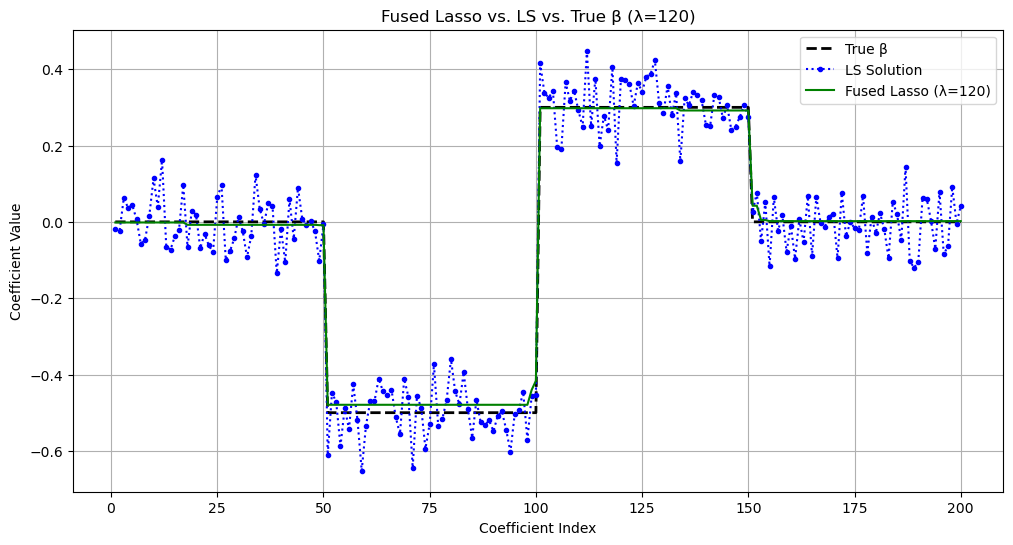

In [76]:
# your solution
beta_fl_30 = ADMM_FL(X, y, lam=30)
beta_fl_120 = ADMM_FL(X, y, lam=120)

beta_ls, _, _, _ = np.linalg.lstsq(X, y, rcond=None)
beta_ls = beta_ls.flatten()

beta_true = be.flatten()

indices = np.arange(1, p + 1)

plt.figure(figsize=(12, 6))
plt.plot(indices, beta_true, 'k--', linewidth=2, label='True β')
plt.plot(indices, beta_ls, 'b:', marker='.', label='LS Solution')
plt.plot(indices, beta_fl_30, 'r-', label='Fused Lasso (λ=30)')
plt.xlabel("Coefficient Index")
plt.ylabel("Coefficient Value")
plt.title("Fused Lasso vs. LS vs. True β (λ=30)")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(indices, beta_true, 'k--', linewidth=2, label='True β')
plt.plot(indices, beta_ls, 'b:', marker='.', label='LS Solution')
plt.plot(indices, beta_fl_120, 'g-', label='Fused Lasso (λ=120)')
plt.xlabel("Coefficient Index")
plt.ylabel("Coefficient Value")
plt.title("Fused Lasso vs. LS vs. True β (λ=120)")
plt.legend()
plt.grid(True)
plt.show()